# Perceptron single-layer sur Breast Cancer Wisconsin

Objectif: classifier une tumeur (`malignant` ou `benign`) avec un Perceptron (une seule couche linéaire).

Pipeline:
1. Chargement des données Breast Cancer Wisconsin (scikit-learn)
2. Standardisation des variables
3. Entraînement du Perceptron
4. Évaluation et visualisation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [5]:
# 1) Chargement des donnees
bc = load_breast_cancer()
X = bc.data
y = bc.target

print(f"Shape X: {X.shape}")
print(f"Classes: {bc.target_names}")
print(f"Distribution classes: {np.bincount(y)}")

# 2) Split train/val/test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# 3) Standardisation (important pour le Perceptron)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape[0]}")
print(f"Validation size: {X_val_scaled.shape[0]}")
print(f"Test size: {X_test_scaled.shape[0]}")

Shape X: (569, 30)
Classes: ['malignant' 'benign']
Distribution classes: [212 357]
Train size: 398
Validation size: 85
Test size: 86


In [8]:
# 4) Entrainement d'un Perceptron single-layer - recherche du meilleur epoch par validation
import copy

best_val_acc = -1
best_model = None
best_epoch_init = -1

# Entraîner un modèle initial et chercher le meilleur selon validation
perceptron = Perceptron(
    max_iter=1,
    eta0=0.01,
    random_state=42,
    tol=None,
    shuffle=True,
    warm_start=True
)

classes = np.unique(y_train)

# Entraînement rapide pour trouver le meilleur epoch via validation
for epoch in range(50):
    if epoch == 0:
        perceptron.partial_fit(X_train_scaled, y_train, classes=classes)
    else:
        perceptron.partial_fit(X_train_scaled, y_train)
    
    val_acc_temp = perceptron.score(X_val_scaled, y_val)
    
    if val_acc_temp > best_val_acc:
        best_val_acc = val_acc_temp
        best_model = copy.deepcopy(perceptron)
        best_epoch_init = epoch + 1

print(f"Meilleur epoch trouve (validation): {best_epoch_init}")
print(f"Accuracy validation au meilleur epoch: {best_val_acc:.4f}")


Meilleur epoch trouve (validation): 3
Accuracy validation au meilleur epoch: 0.9882


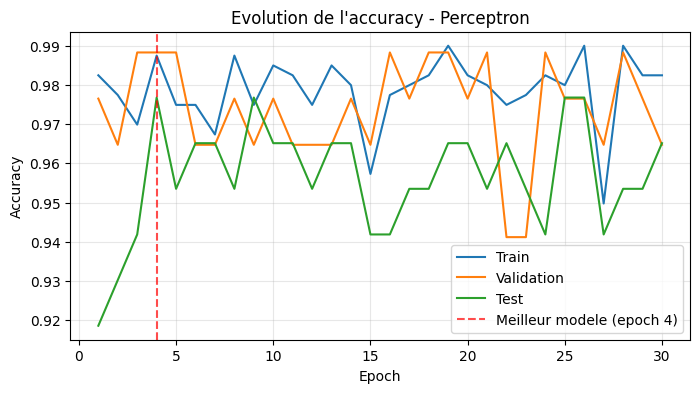

Meilleure accuracy validation observee: 0.9882
Meilleure accuracy test observee: 0.9767 (epoch 4)


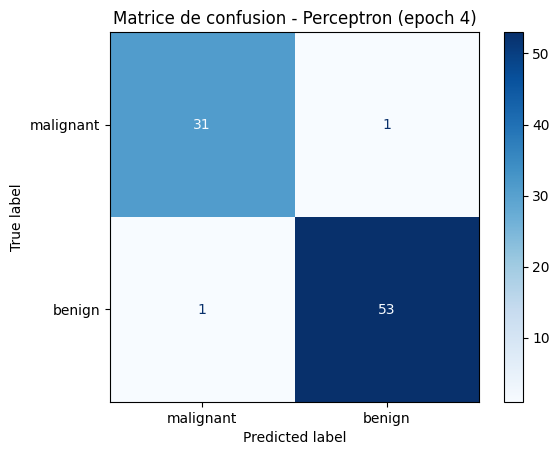


Rapport de classification (meilleur modele):
              precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        32
      benign       0.98      0.98      0.98        54

    accuracy                           0.98        86
   macro avg       0.98      0.98      0.98        86
weighted avg       0.98      0.98      0.98        86



In [10]:
# 5) Suivi detaille de l'accuracy par epoch avec partial_fit + matrice de confusion du meilleur modele
classes = np.unique(y_train)
model_epoch = Perceptron(
    max_iter=1,
    eta0=0.01,
    tol=None,
    shuffle=True,
    random_state=42,
    warm_start=True
)

epochs = 30
train_acc_history = []
val_acc_history = []
test_acc_history = []

best_test_acc = -1
best_model_detailed = None
best_epoch_detailed = -1

for epoch in range(epochs):
    if epoch == 0:
        model_epoch.partial_fit(X_train_scaled, y_train, classes=classes)
    else:
        model_epoch.partial_fit(X_train_scaled, y_train)

    train_acc = model_epoch.score(X_train_scaled, y_train)
    val_acc = model_epoch.score(X_val_scaled, y_val)
    test_acc = model_epoch.score(X_test_scaled, y_test)
    
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    test_acc_history.append(test_acc)
    
    # Sauvegarder le meilleur modele selon accuracy test
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_detailed = copy.deepcopy(model_epoch)
        best_epoch_detailed = epoch + 1

plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_acc_history, label="Train")
plt.plot(range(1, epochs + 1), val_acc_history, label="Validation")
plt.plot(range(1, epochs + 1), test_acc_history, label="Test")
plt.axvline(x=best_epoch_detailed, color='red', linestyle='--', alpha=0.7, label=f"Meilleur modele (epoch {best_epoch_detailed})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolution de l'accuracy - Perceptron")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Meilleure accuracy validation observee: {max(val_acc_history):.4f}")
print(f"Meilleure accuracy test observee: {best_test_acc:.4f} (epoch {best_epoch_detailed})")

# Matrice de confusion avec le meilleur modele
y_best_pred = best_model_detailed.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_best_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bc.target_names).plot(cmap="Blues")
plt.title(f"Matrice de confusion - Perceptron (epoch {best_epoch_detailed})")
plt.show()

print("\nRapport de classification (meilleur modele):")
print(classification_report(y_test, y_best_pred, target_names=bc.target_names))